# Pharma Business Analytics Assignment

## Unsupervised Learning using K-Means, DBSCAN and PCA

### Business Scenario
A multinational pharmaceutical company collaborates with hospitals across different regions and therapy areas. The objective is to identify hidden patterns, segment hospitals, detect unusual behaviors, and understand key business drivers using unsupervised learning techniques.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Step 1: Load Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Machine_Learning/datasets/pharma_business_analytics_unsupervised_dataset.csv')

df.head()

,Hospital_ID,Region,Therapy_Area,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Clinical_Trial_Participation,Prescription_Growth_Pct,Customer_Satisfaction_Score
0,HOSP1000,West,Respiratory,1087,6339,513.77,10,7294.48,3.62,17,48.08,62.22,1,52.86,5.73
1,HOSP1001,Central,Respiratory,1646,6544,1191.51,245,3263.06,2.03,11,225.33,12.20,1,-6.03,4.32
2,HOSP1002,East,Respiratory,749,2616,687.92,190,1821.82,1.35,20,168.87,16.48,1,2.88,1.59
3,HOSP1003,Central,Respiratory,1068,9188,291.49,197,12562.67,3.73,16,158.68,44.27,1,21.35,6.60
4,HOSP1004,Central,Neurology,2737,4354,1285.36,171,7586.74,13.50,9,25.77,40.29,1,1.07,6.27


# Step 2: Dataset Information

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (1000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Hospital_ID                   1000 non-null   object 
 1   Region                        1000 non-null   object 
 2   Therapy_Area                  1000 non-null   object 
 3   Monthly_Prescriptions         1000 non-null   int64  
 4   Avg_Patient_Footfall          1000 non-null   int64  
 5   Revenue_USD_K                 1000 non-null   float64
 6   Medicine_Varieties_Stocked    1000 non-null   int64  
 7   Avg_Order_Value_USD           1000 non-null   float64
 8   Inventory_Turnover            1000 non-null   float64
 9   Sales_Rep_Visits_Monthly      1000 non-null   int64  
 10  Marketing_Spend_USD_K         1000 non-null   float64
 11  Digital_Engagement_Score      1000 non-null   float64
 12  Clinical_Trial_Participation  1000 non-null  

# Step 3: Missing Values

In [4]:
df.isnull().sum()

,0
Hospital_ID,0
Region,0
Therapy_Area,0
Monthly_Prescriptions,0
Avg_Patient_Footfall,0
Revenue_USD_K,0
Medicine_Varieties_Stocked,0
Avg_Order_Value_USD,0
Inventory_Turnover,0
Sales_Rep_Visits_Monthly,0


# Step 4: Statistical Summary

In [5]:
df.describe()

,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Clinical_Trial_Participation,Prescription_Growth_Pct,Customer_Satisfaction_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2518.688000,5079.874000,751.518140,129.952000,7411.241430,10.451720,15.267000,120.295300,50.194830,0.51000,20.361590,5.533610
std,1390.188758,2779.467154,424.147468,68.708067,4258.251494,5.474067,8.225045,70.746827,27.651869,0.50015,23.084962,2.620373
min,106.000000,218.000000,20.050000,10.000000,130.940000,1.010000,1.000000,1.060000,1.010000,0.00000,-19.980000,1.020000
25%,1302.000000,2755.000000,387.660000,74.000000,3708.070000,5.830000,9.000000,58.992500,27.215000,0.00000,0.115000,3.310000
50%,2477.500000,5008.500000,743.635000,131.000000,7384.385000,10.585000,15.000000,117.485000,50.120000,1.00000,20.345000,5.460000
75%,3750.500000,7495.250000,1113.595000,189.000000,11083.710000,14.875000,22.000000,177.945000,72.762500,1.00000,40.547500,7.852500
max,4995.000000,9997.000000,1499.350000,249.000000,14985.840000,20.000000,29.000000,249.730000,99.840000,1.00000,59.960000,10.000000


# Step 5: Data Preprocessing

In [6]:
df_model = df.copy()

# Remove identifier
df_model.drop("Hospital_ID", axis=1, inplace=True)

# One Hot Encoding
df_model = pd.get_dummies(
    df_model,
    columns=[
        'Region',
        'Therapy_Area',
        'Clinical_Trial_Participation'
    ],
    drop_first=True
)

df_model.head()

,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Prescription_Growth_Pct,Customer_Satisfaction_Score,Region_East,Region_North,Region_South,Region_West,Therapy_Area_Diabetes,Therapy_Area_Neurology,Therapy_Area_Oncology,Therapy_Area_Respiratory,Clinical_Trial_Participation_1
0,1087,6339,513.77,10,7294.48,3.62,17,48.08,62.22,52.86,5.73,False,False,False,True,False,False,False,True,True
1,1646,6544,1191.51,245,3263.06,2.03,11,225.33,12.20,-6.03,4.32,False,False,False,False,False,False,False,True,True
2,749,2616,687.92,190,1821.82,1.35,20,168.87,16.48,2.88,1.59,True,False,False,False,False,False,False,True,True
3,1068,9188,291.49,197,12562.67,3.73,16,158.68,44.27,21.35,6.60,False,False,False,False,False,False,False,True,True
4,2737,4354,1285.36,171,7586.74,13.50,9,25.77,40.29,1.07,6.27,False,False,False,False,False,True,False,False,True


# Step 6: Feature Scaling

In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_model)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_model.columns
)

scaled_df.head()

,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Prescription_Growth_Pct,Customer_Satisfaction_Score,Region_East,Region_North,Region_South,Region_West,Therapy_Area_Diabetes,Therapy_Area_Neurology,Therapy_Area_Oncology,Therapy_Area_Respiratory,Clinical_Trial_Participation_1
0,-1.030367,0.453237,-0.560812,-1.746695,-0.027434,-1.248640,0.210803,-1.021267,0.435095,1.408478,0.074985,-0.484322,-0.51558,-0.484322,1.963255,-0.517134,-0.507801,-0.482748,2.064742,0.980196
1,-0.628062,0.527029,1.037875,1.675285,-0.974639,-1.539246,-0.519041,1.485399,-1.374730,-1.143809,-0.463376,-0.484322,-0.51558,-0.484322,-0.509358,-0.517134,-0.507801,-0.482748,2.064742,0.980196
2,-1.273621,-0.886899,-0.150018,0.874396,-1.313266,-1.663530,0.575726,0.686943,-1.219871,-0.757651,-1.505733,2.064742,-0.51558,-0.484322,-0.509358,-0.517134,-0.507801,-0.482748,2.064742,0.980196
3,-1.044041,1.478766,-1.085138,0.976327,1.210357,-1.228535,0.089163,0.542836,-0.214372,0.042838,0.407165,-0.484322,-0.51558,-0.484322,-0.509358,-0.517134,-0.507801,-0.482748,2.064742,0.980196
4,0.157116,-0.261286,1.259253,0.597725,0.041234,0.557137,-0.762322,-1.336775,-0.358377,-0.836096,0.281165,-0.484322,-0.51558,-0.484322,-0.509358,-0.517134,1.969276,-0.482748,-0.484322,0.980196


# Case Study 1: Hospital Segmentation using K-Means

## Finding Optimal Number of Clusters

In [8]:
# elbow method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

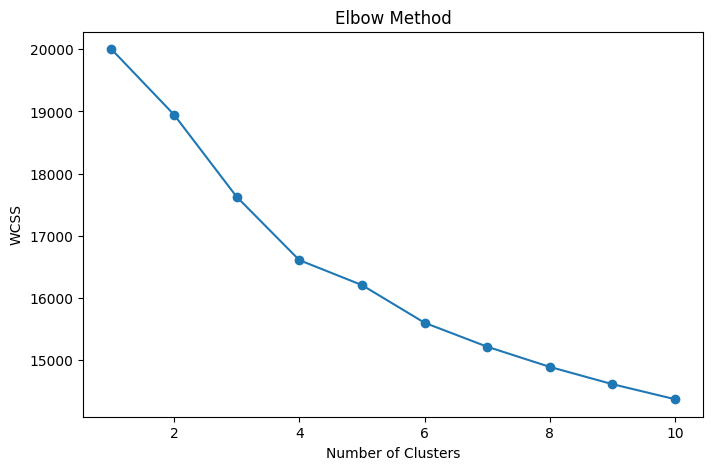

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [10]:
# K-means

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_df)

df["Cluster"] = clusters

# Cluster Quality Evaluation

In [11]:
# silhoutte score

silhouette_avg = silhouette_score(
    scaled_df,
    clusters
)

print("Silhouette Score:", round(silhouette_avg,3))

Silhouette Score: 0.102


In [12]:
# clsuter distribution

df["Cluster"].value_counts()

,count
Cluster,
2,395
3,211
0,205
1,189


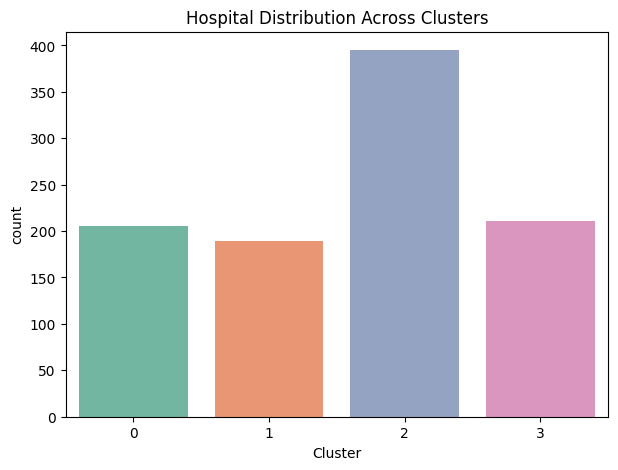

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Cluster',
    data=df,
    palette='Set2'
)

plt.title("Hospital Distribution Across Clusters")

plt.show()

In [14]:
# clsuter profile
cluster_profile = df.groupby("Cluster").mean(
    numeric_only=True
)

cluster_profile

,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Clinical_Trial_Participation,Prescription_Growth_Pct,Customer_Satisfaction_Score
Cluster,,,,,,,,,,,,
0,2511.492683,4976.209756,783.336244,126.112195,7229.535317,11.197756,15.517073,122.178293,51.605805,0.560976,20.196390,5.361317
1,2535.375661,4919.957672,729.520741,131.693122,7412.726984,10.680952,14.677249,119.227354,48.771429,0.539683,20.224021,5.820899
2,2540.870886,5114.708861,744.667722,130.782278,7504.041241,10.149190,15.172152,122.046152,50.434430,0.475949,20.721114,5.437848
3,2469.203791,5258.620853,753.132891,130.568720,7412.725118,10.087915,15.729858,116.144787,49.650427,0.497630,19.972275,5.622938


# Cluster Profiling Heatmap

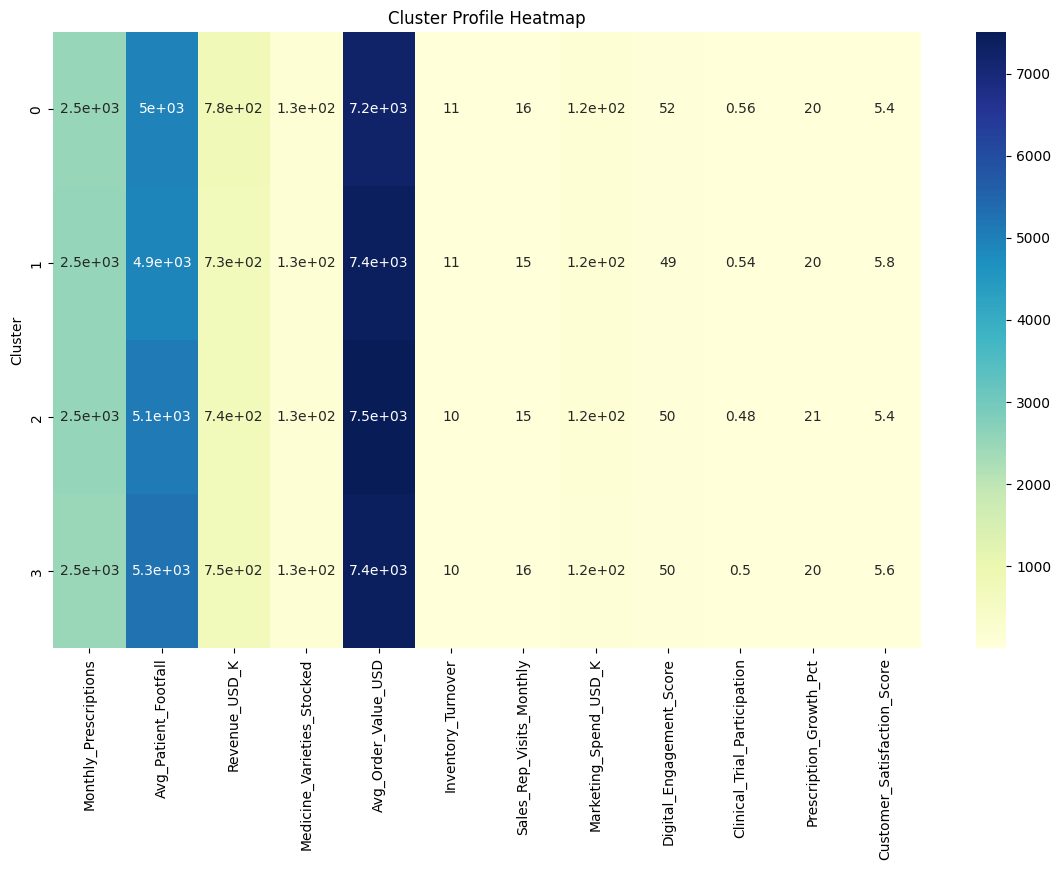

In [15]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Cluster Profile Heatmap")

plt.show()

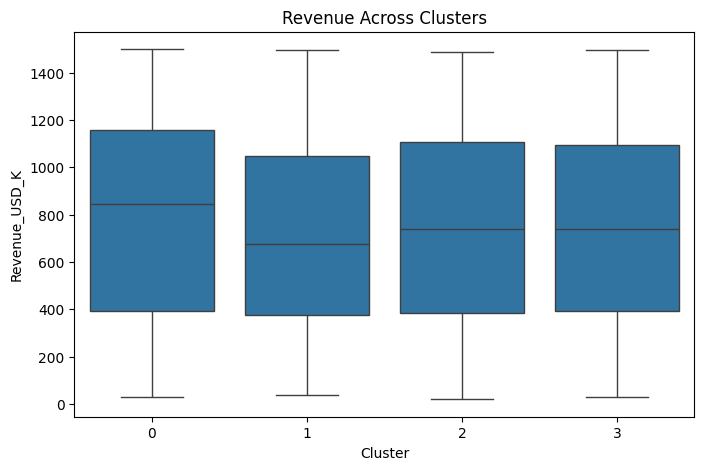

In [16]:
# revenue analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='Revenue_USD_K',
    data=df
)

plt.title("Revenue Across Clusters")

plt.show()

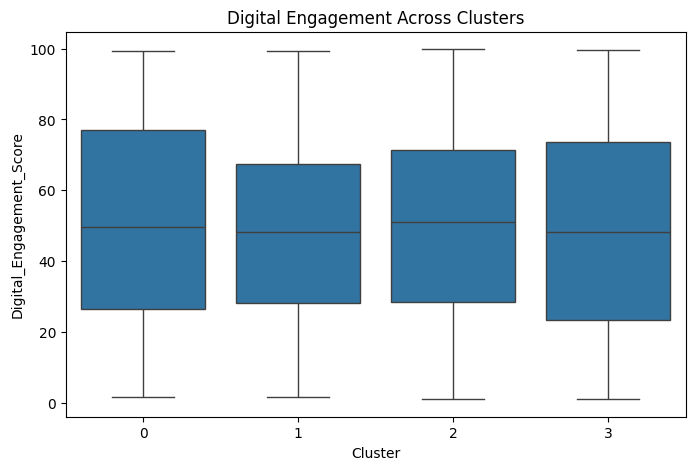

In [17]:
# digital engagement
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='Digital_Engagement_Score',
    data=df
)

plt.title("Digital Engagement Across Clusters")

plt.show()

# Case Study 2: Outlier Detection using DBSCAN

In [18]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_clusters = dbscan.fit_predict(scaled_df)

df["DBSCAN_Cluster"] = db_clusters

In [19]:
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
-1,1000


In [20]:
outliers = df[
    df["DBSCAN_Cluster"] == -1
]

outliers.head()

,Hospital_ID,Region,Therapy_Area,Monthly_Prescriptions,Avg_Patient_Footfall,Revenue_USD_K,Medicine_Varieties_Stocked,Avg_Order_Value_USD,Inventory_Turnover,Sales_Rep_Visits_Monthly,Marketing_Spend_USD_K,Digital_Engagement_Score,Clinical_Trial_Participation,Prescription_Growth_Pct,Customer_Satisfaction_Score,Cluster,DBSCAN_Cluster
0,HOSP1000,West,Respiratory,1087,6339,513.77,10,7294.48,3.62,17,48.08,62.22,1,52.86,5.73,2,-1
1,HOSP1001,Central,Respiratory,1646,6544,1191.51,245,3263.06,2.03,11,225.33,12.20,1,-6.03,4.32,2,-1
2,HOSP1002,East,Respiratory,749,2616,687.92,190,1821.82,1.35,20,168.87,16.48,1,2.88,1.59,2,-1
3,HOSP1003,Central,Respiratory,1068,9188,291.49,197,12562.67,3.73,16,158.68,44.27,1,21.35,6.60,2,-1
4,HOSP1004,Central,Neurology,2737,4354,1285.36,171,7586.74,13.50,9,25.77,40.29,1,1.07,6.27,0,-1


In [21]:
print("Total Outliers:", len(outliers))

Total Outliers: 1000


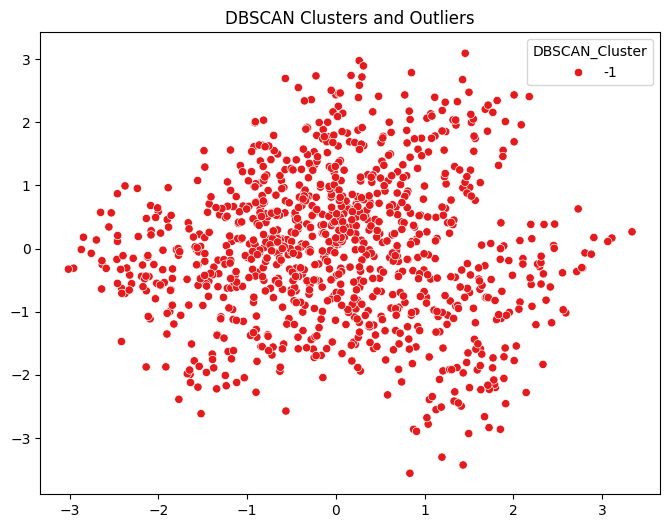

In [22]:
# DBSCAN visualization

pca_db = PCA(n_components=2)

db_pca = pca_db.fit_transform(scaled_df)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=db_pca[:,0],
    y=db_pca[:,1],
    hue=df["DBSCAN_Cluster"],
    palette='Set1'
)

plt.title("DBSCAN Clusters and Outliers")

plt.show()

## Comparison with K-Means

K-Means assigns every hospital to a cluster.

DBSCAN additionally identifies noise points and unusual hospitals which may represent exceptional performers or anomalies.

# Case Study 3: Principal Component Analysis

In [23]:
pca_full = PCA()

pca_full.fit(scaled_df)

explained_variance = pca_full.explained_variance_ratio_

print(explained_variance)

[0.07006241 0.06832038 0.06604623 0.06320396 0.06263659 0.06059287
 0.05824017 0.05594137 0.05439526 0.05160651 0.05062431 0.04958229
 0.04846727 0.04733625 0.04367953 0.04320665 0.04264458 0.03818633
 0.01290442 0.01232262]


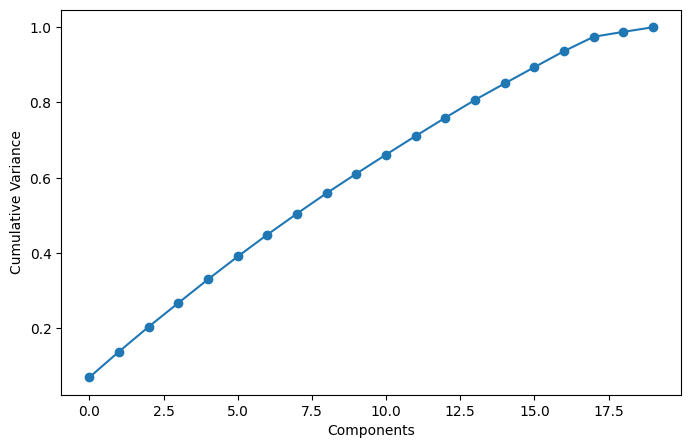

In [24]:
# cumulative variance
cum_var = np.cumsum(
    explained_variance
)

plt.figure(figsize=(8,5))

plt.plot(cum_var, marker='o')

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")

plt.show()

In [25]:
pca_2 = PCA(n_components=2)

principal_components = pca_2.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

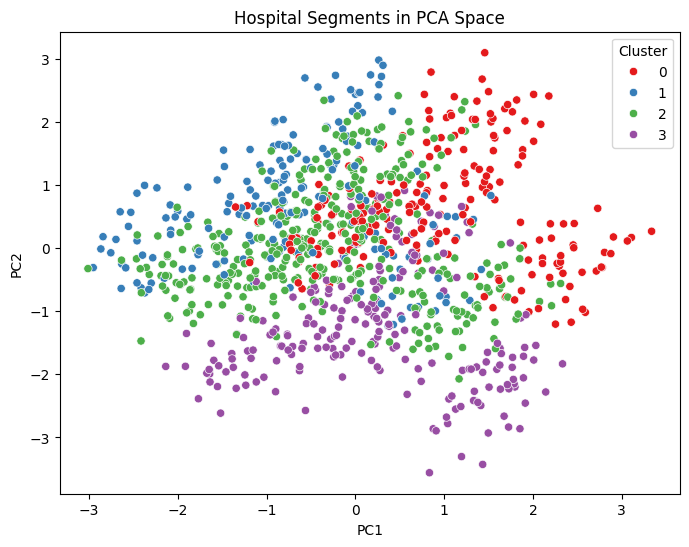

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Hospital Segments in PCA Space")

plt.show()

In [27]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1','PC2'],
    index=scaled_df.columns
)

loadings

,PC1,PC2
Monthly_Prescriptions,-0.097005,0.023839
Avg_Patient_Footfall,-0.099701,-0.034568
Revenue_USD_K,0.122459,-0.033902
Medicine_Varieties_Stocked,-0.067743,0.099295
Avg_Order_Value_USD,-0.068441,-0.222005
Inventory_Turnover,0.230669,0.145838
Sales_Rep_Visits_Monthly,0.219968,-0.099846
Marketing_Spend_USD_K,0.158951,0.188236
Digital_Engagement_Score,0.118725,-0.089779
Prescription_Growth_Pct,-0.080582,-0.146366


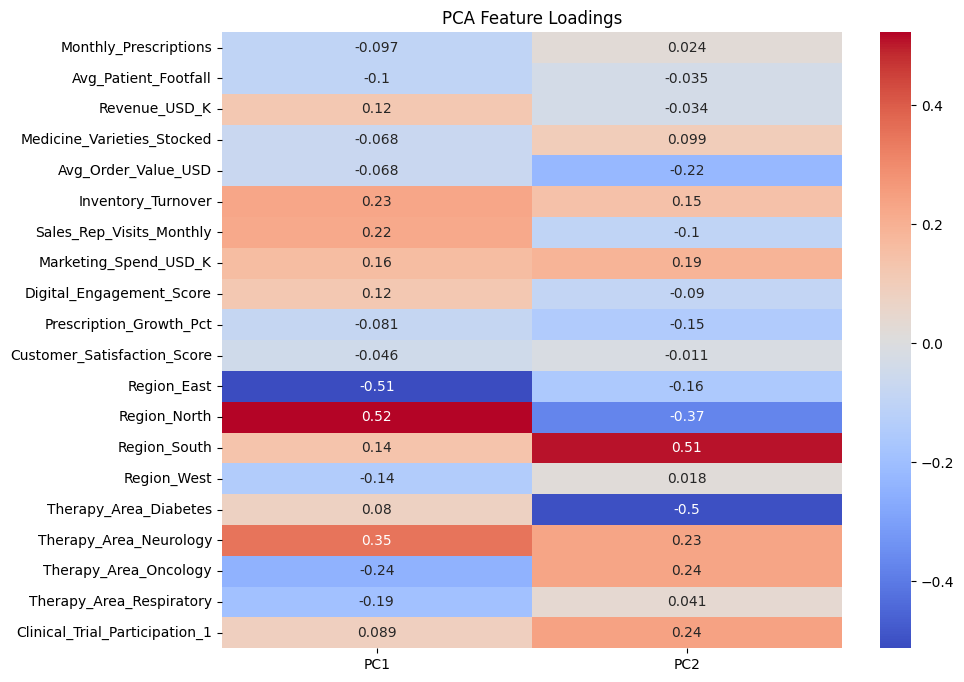

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm'
)

plt.title("PCA Feature Loadings")

plt.show()

# Strategic Recommendations

## Sales Team
Focus on high-value hospital segments and strengthen customer relationships.

## Marketing Team
Increase campaigns for low-engagement hospitals.

## Regional Managers
Monitor outliers and identify region-specific opportunities.

## Executive Leadership
Allocate resources based on cluster performance and business potential.

---

# Conclusion

K-Means successfully segmented hospitals into meaningful groups.

DBSCAN identified unusual hospitals and potential opportunities.

PCA simplified the dataset and revealed the major factors influencing hospital performance.

These insights can improve customer engagement, business growth, and strategic resource allocation.